In [1]:
pip install pandas matplotlib seaborn scikit-learn


In [2]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [3]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

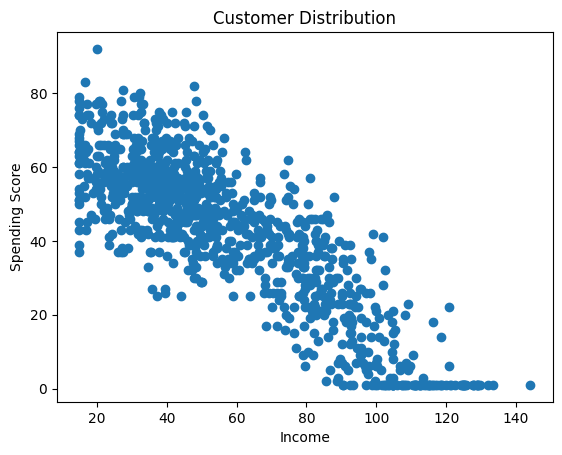

In [4]:
import matplotlib.pyplot as plt

plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")
plt.show()

In [6]:
X.isnull().sum()

,0
Annual Income (k$),4
Spending Score (1-100),6


In [7]:
X = X.dropna()

In [8]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

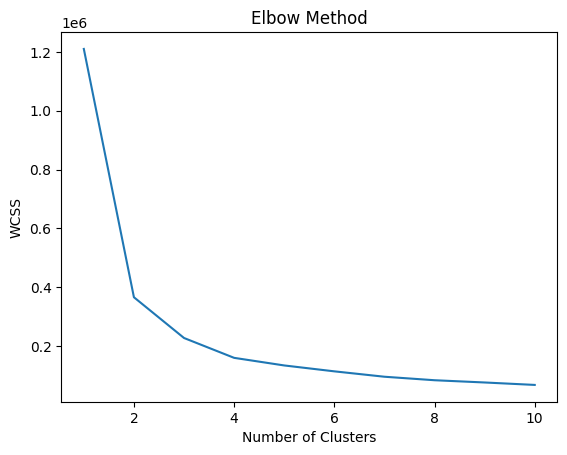

In [9]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [10]:
kmeans = KMeans(n_clusters=5, random_state=0)
y_kmeans = kmeans.fit_predict(X)

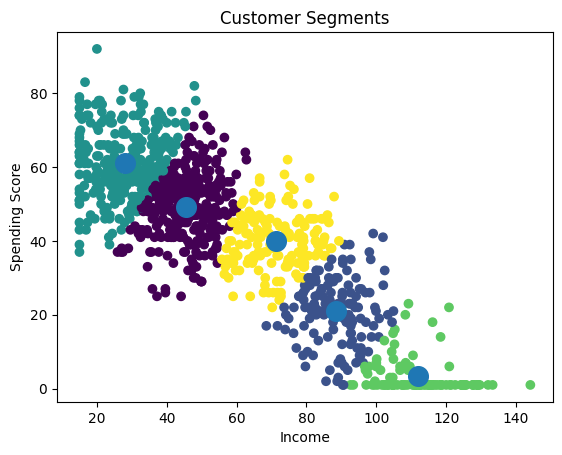

In [11]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y_kmeans)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200)
plt.title("Customer Segments")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

-Identified 5 distinct customer groups based on income and spending behavior.
-Customers with high income & high spending are premium targets for marketing
-Customers with high income but low spending show potential for conversion strategies
-Low income & low spending customers represent budget-conscious segments
-Mid-range groups indicate average purchasing behavior and stable engagement